In [1]:
%cd ..

C:\Users\ausar\Desktop\LABS4\final\ZoloZip


In [2]:
!pip install -q seaborn tqdm

In [3]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

sns.set_theme(style="whitegrid", font_scale=1.2)
sys.path.insert(0, ".")

from ngram_model import NgramModel

DATASET_NAME = "enwik6"
CHUNK_SIZES = [128, 256, 512, 1024, 2048]
GLOBAL_POS_BINS = 2048  # агрегация позиции для одного global-прогона: t % GLOBAL_POS_BINS
NGRAM_ORDER = 4
MAX_TOKENS = None
TOK_NAME = "custom_spm"

PANEL_PAIRS = [(128, 256), (256, 512), (512, 1024), (1024, 2048)]
XTICKS = [0, 128, 256, 512, 1024, 2048]

# Пороги «лёгких» токенов в bpb — см. ячейку загрузки данных (после BPT_TO_BPB).

In [4]:
import sentencepiece as spm
from oov_utils import extract_oov_from_text

with open("data/enwik6", "r", encoding="utf-8") as f:
    text = f.read()
N_BYTES = len(text.encode("utf-8"))
print(f"Characters: {len(text):,}  UTF-8 bytes: {N_BYTES:,}")

_sp = spm.SentencePieceProcessor()
_sp.load("models/tokenizer.model")
tokens = extract_oov_from_text(text, _sp).filtered_ids
vocab_size = len(_sp)
if MAX_TOKENS is not None:
    tokens = tokens[:MAX_TOKENS]

BPT_TO_BPB = len(tokens) / N_BYTES
print(f"  {TOK_NAME}: {len(tokens):,} tokens, vocab={vocab_size:,}  bytes/token≈{N_BYTES/len(tokens):.3f}")
print(f"  bpb multiplier (tokens/bytes): {BPT_TO_BPB:.6f}")

# Лёгкий токен: (−log2 p_top1) * BPT_TO_BPB <= порога (тот же масштаб «сюрприза», что у avg_top1_bpb на позицию).
# Замени список вручную в bpb или оставь формулу из эталонных p:
K_EASY_MAX_TOP1_SURPRISE_BPB = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5]

Characters: 995,768  UTF-8 bytes: 1,000,000


  custom_spm: 259,546 tokens, vocab=16,384  bytes/token≈3.853
  bpb multiplier (tokens/bytes): 0.259546


In [5]:
def run_global_experiment(tokens: list[int], vocab_size: int, pos_bins: int):
    """Один последовательный прогон: память и context не сбрасываются.
    Позиция для усреднения: t % pos_bins (pos_bins=2048).
    Возвращает также ce (бит/токен), p_top1 по каждому токену (для easy-метрик по K_EASY_MAX_TOP1_SURPRISE_BPB)."""
    model = NgramModel(max_order=NGRAM_ORDER, vocab_size=vocab_size)
    n = len(tokens)
    ce_arr = np.empty(n, dtype=np.float32)
    ptop_arr = np.empty(n, dtype=np.float32)
    context: list[int] = []

    total_entropy = 0.0
    total_top1_ent = 0.0
    total_tokens = 0
    M2 = 0.0
    mean_ent = 0.0

    pos_acc = defaultdict(lambda: [0.0, 0.0, 0])  # sum_ent, sum_top1, count

    for t, token in enumerate(tokens):
        probs = model.predict(context)
        p_real = max(float(probs[token]), 1e-12)
        entropy = -np.log2(p_real)
        p_top1 = max(float(np.max(probs)), 1e-12)
        top1_ent = -np.log2(p_top1)

        ce_arr[t] = np.float32(entropy)
        ptop_arr[t] = np.float32(p_top1)

        total_tokens += 1
        total_entropy += entropy
        total_top1_ent += top1_ent

        delta = entropy - mean_ent
        mean_ent += delta / total_tokens
        M2 += delta * (entropy - mean_ent)

        pos = t % pos_bins
        acc = pos_acc[pos]
        acc[0] += entropy
        acc[1] += top1_ent
        acc[2] += 1

        model.update(context, token)
        context.append(token)
        if len(context) > NGRAM_ORDER - 1:
            context = context[-(NGRAM_ORDER - 1) :]

    std_ent = np.sqrt(M2 / total_tokens) if total_tokens > 1 else 0.0
    summary = {
        "total_tokens": total_tokens,
        "avg_entropy": total_entropy / total_tokens,
        "std_entropy": std_ent,
        "avg_top1_entropy": total_top1_ent / total_tokens,
    }
    pos_rows = {}
    for pos, (s_ent, s_top, cnt) in pos_acc.items():
        pos_rows[pos] = {
            "avg_entropy": s_ent / cnt,
            "avg_top1_entropy": s_top / cnt,
            "count": cnt,
        }
    return summary, pos_rows, ce_arr, ptop_arr


def run_reset_experiment(tokens: list[int], vocab_size: int, chunk_size: int):
    """Сброс модели и context на каждом чанке длины chunk_size."""
    model = NgramModel(max_order=NGRAM_ORDER, vocab_size=vocab_size)
    n = len(tokens)
    ce_arr = np.empty(n, dtype=np.float32)
    ptop_arr = np.empty(n, dtype=np.float32)
    idx = 0

    total_entropy = 0.0
    total_top1_ent = 0.0
    total_tokens = 0
    M2 = 0.0
    mean_ent = 0.0
    pos_acc = defaultdict(lambda: [0.0, 0.0, 0])

    for offset in tqdm(range(0, n, chunk_size), desc=f"reset cs={chunk_size}"):
        chunk = tokens[offset : offset + chunk_size]
        model.reset()
        context: list[int] = []
        for i, token in enumerate(chunk):
            probs = model.predict(context)
            p_real = max(float(probs[token]), 1e-12)
            entropy = -np.log2(p_real)
            p_top1 = max(float(np.max(probs)), 1e-12)
            top1_ent = -np.log2(p_top1)

            ce_arr[idx] = np.float32(entropy)
            ptop_arr[idx] = np.float32(p_top1)
            idx += 1

            total_tokens += 1
            total_entropy += entropy
            total_top1_ent += top1_ent

            delta = entropy - mean_ent
            mean_ent += delta / total_tokens
            M2 += delta * (entropy - mean_ent)

            acc = pos_acc[i]
            acc[0] += entropy
            acc[1] += top1_ent
            acc[2] += 1

            model.update(context, token)
            context.append(token)
            if len(context) > NGRAM_ORDER - 1:
                context = context[-(NGRAM_ORDER - 1) :]

    assert idx == n
    std_ent = np.sqrt(M2 / total_tokens) if total_tokens > 1 else 0.0
    summary = {
        "total_tokens": total_tokens,
        "avg_entropy": total_entropy / total_tokens,
        "std_entropy": std_ent,
        "avg_top1_entropy": total_top1_ent / total_tokens,
    }
    pos_rows = {}
    for pos, (s_ent, s_top, cnt) in pos_acc.items():
        pos_rows[pos] = {
            "avg_entropy": s_ent / cnt,
            "avg_top1_entropy": s_top / cnt,
            "count": cnt,
        }
    return summary, pos_rows, ce_arr, ptop_arr


def easy_token_bpb_by_threshold(
    ce: np.ndarray,
    ptop: np.ndarray,
    max_top1_surprise_bpb_list: list[float],
    bpb_mul: float,
) -> list[dict]:
    """Средний bpb (CE истинного) только там, где (−log2 p_top1)*bpb_mul <= порога."""
    n = int(ce.shape[0])
    p64 = np.maximum(ptop.astype(np.float64), 1e-30)
    surprise_bpb = (-np.log2(p64)) * bpb_mul
    rows: list[dict] = []
    for thr in max_top1_surprise_bpb_list:
        m = surprise_bpb <= thr
        cnt = int(np.count_nonzero(m))
        if cnt == 0:
            rows.append(
                {
                    "max_top1_surprise_bpb": thr,
                    "easy_bpb": float("nan"),
                    "pct_easy": 0.0,
                    "n_easy": 0,
                }
            )
        else:
            rows.append(
                {
                    "max_top1_surprise_bpb": thr,
                    "easy_bpb": float(np.mean(ce[m]) * bpb_mul),
                    "pct_easy": round(100.0 * cnt / n, 1),
                    "n_easy": cnt,
                }
            )
    return rows

In [6]:
summary_rows = []
position_rows = []
easy_rows = []

print(f"[{TOK_NAME}] global sequential (pos_bins={GLOBAL_POS_BINS})...")
t0 = time.time()
summary_g, pos_g, ce_g, ptop_g = run_global_experiment(
    tokens, vocab_size, GLOBAL_POS_BINS
)
elapsed_g = time.time() - t0

summary_rows.append(
    {
        "mode": "global",
        "chunk_size": GLOBAL_POS_BINS,
        "avg_entropy": summary_g["avg_entropy"],
        "avg_bpb": summary_g["avg_entropy"] * BPT_TO_BPB,
        "std_entropy": summary_g["std_entropy"],
        "avg_top1_entropy": summary_g["avg_top1_entropy"],
        "avg_top1_bpb": summary_g["avg_top1_entropy"] * BPT_TO_BPB,
        "total_tokens": summary_g["total_tokens"],
        "time_sec": round(elapsed_g, 1),
    }
)
for pos, pdata in pos_g.items():
    position_rows.append(
        {
            "mode": "global",
            "chunk_size": GLOBAL_POS_BINS,
            "pos_in_chunk": pos,
            "avg_entropy": pdata["avg_entropy"],
            "avg_bpb": pdata["avg_entropy"] * BPT_TO_BPB,
            "avg_top1_entropy": pdata["avg_top1_entropy"],
            "avg_top1_bpb": pdata["avg_top1_entropy"] * BPT_TO_BPB,
            "n_chunks": pdata["count"],
        }
    )
print(
    f"  global avg_bpb={summary_g['avg_entropy'] * BPT_TO_BPB:.4f}  "
    f"top1_bpb={summary_g['avg_top1_entropy'] * BPT_TO_BPB:.4f}  ({elapsed_g:.1f}s)"
)
for row in easy_token_bpb_by_threshold(
    ce_g, ptop_g, K_EASY_MAX_TOP1_SURPRISE_BPB, BPT_TO_BPB
):
    easy_rows.append(
        {
            "mode": "global",
            "chunk_size": GLOBAL_POS_BINS,
            **row,
        }
    )

for cs in CHUNK_SIZES:
    print(f"[{TOK_NAME}] reset cs={cs}...")
    t0 = time.time()
    summary, pos_data, ce_r, ptop_r = run_reset_experiment(tokens, vocab_size, cs)
    elapsed = time.time() - t0
    summary_rows.append(
        {
            "mode": "reset_each_chunk",
            "chunk_size": cs,
            "avg_entropy": summary["avg_entropy"],
            "avg_bpb": summary["avg_entropy"] * BPT_TO_BPB,
            "std_entropy": summary["std_entropy"],
            "avg_top1_entropy": summary["avg_top1_entropy"],
            "avg_top1_bpb": summary["avg_top1_entropy"] * BPT_TO_BPB,
            "total_tokens": summary["total_tokens"],
            "time_sec": round(elapsed, 1),
        }
    )
    for pos, pdata in pos_data.items():
        position_rows.append(
            {
                "mode": "reset_each_chunk",
                "chunk_size": cs,
                "pos_in_chunk": pos,
                "avg_entropy": pdata["avg_entropy"],
                "avg_bpb": pdata["avg_entropy"] * BPT_TO_BPB,
                "avg_top1_entropy": pdata["avg_top1_entropy"],
                "avg_top1_bpb": pdata["avg_top1_entropy"] * BPT_TO_BPB,
                "n_chunks": pdata["count"],
            }
        )
    print(
        f"  reset cs={cs} avg_bpb={summary['avg_entropy'] * BPT_TO_BPB:.4f}  "
        f"({elapsed:.1f}s)"
    )
    for row in easy_token_bpb_by_threshold(
        ce_r, ptop_r, K_EASY_MAX_TOP1_SURPRISE_BPB, BPT_TO_BPB
    ):
        easy_rows.append(
            {
                "mode": "reset_each_chunk",
                "chunk_size": cs,
                **row,
            }
        )

df_easy = pd.DataFrame(easy_rows)
df_summary = pd.DataFrame(summary_rows)
df_position = pd.DataFrame(position_rows)
print(f"\ndf_easy: {df_easy.shape}  df_summary: {df_summary.shape}  df_position: {df_position.shape}")
df_summary

[custom_spm] global sequential (pos_bins=2048)...


  global avg_bpb=2.4258  top1_bpb=0.5618  (43.1s)
[custom_spm] reset cs=128...


reset cs=128:   0%|                                                                           | 0/2028 [00:00<?, ?it/s]

reset cs=128:   0%|▏                                                                  | 7/2028 [00:00<00:31, 63.76it/s]

reset cs=128:   1%|▌                                                                 | 16/2028 [00:00<00:26, 76.47it/s]

...

reset cs=2048:  99%|████████████████████████████████████████████████████████████████▍| 126/127 [00:36<00:00,  3.88it/s]

reset cs=2048: 100%|█████████████████████████████████████████████████████████████████| 127/127 [00:36<00:00,  4.34it/s]

reset cs=2048: 100%|█████████████████████████████████████████████████████████████████| 127/127 [00:36<00:00,  3.44it/s]

  reset cs=2048 avg_bpb=2.6205  (36.9s)

df_easy: (78, 6)  df_summary: (6, 9)  df_position: (6016, 8)


,mode,chunk_size,avg_entropy,avg_bpb,std_entropy,avg_top1_entropy,avg_top1_bpb,total_tokens,time_sec
0,global,2048,9.346329,2.425802,8.015554,2.164535,0.561796,259546,43.1
1,reset_each_chunk,128,12.132572,3.148961,4.244587,8.447372,2.192482,259546,24.5
2,reset_each_chunk,256,11.515137,2.988708,4.791560,7.260186,1.884352,259546,26.4
3,reset_each_chunk,512,10.987399,2.851735,5.179635,6.235942,1.618514,259546,27.7
4,reset_each_chunk,1024,10.505879,2.726759,5.486815,5.361832,1.391642,259546,30.0
5,reset_each_chunk,2048,10.096628,2.620539,5.738027,4.609501,1.196378,259546,36.9


In [7]:
g_bpb = df_summary.loc[df_summary["mode"] == "global", "avg_bpb"].iloc[0]
g_top1 = df_summary.loc[df_summary["mode"] == "global", "avg_top1_bpb"].iloc[0]
g_top1_bpb = df_summary.loc[df_summary["mode"] == "global", "avg_top1_bpb"].iloc[0]

deltas = df_summary[df_summary["mode"] == "reset_each_chunk"].copy()
deltas["Δ_bpb"] = deltas["avg_bpb"] - g_bpb
deltas["Δ_top1_bpb"] = deltas["avg_top1_bpb"] - g_top1
deltas["Δ_bpb_%"] = (deltas["Δ_bpb"] / g_bpb * 100).round(3)
deltas = deltas.set_index("chunk_size")[
    ["avg_bpb", "avg_top1_bpb", "Δ_bpb", "Δ_top1_bpb", "Δ_bpb_%", "time_sec"]
]

deltas.style.format(
    {
        "avg_bpb": "{:.4f}",
        "avg_top1_bpb": "{:.4f}",
        "Δ_bpb": "{:+.4f}",
        "Δ_top1_bpb": "{:+.4f}",
        "Δ_bpb_%": "{:+.3f}%",
        "time_sec": "{:.1f}",
    }
).background_gradient(subset=["Δ_bpb"], cmap="Reds")

,avg_bpb,avg_top1_bpb,Δ_bpb,Δ_top1_bpb,Δ_bpb_%,time_sec
chunk_size,,,,,,
128,3.1490,2.1925,+0.7232,+1.6307,+29.811%,24.5
256,2.9887,1.8844,+0.5629,+1.3226,+23.205%,26.4
512,2.8517,1.6185,+0.4259,+1.0567,+17.558%,27.7
1024,2.7268,1.3916,+0.3010,+0.8298,+12.406%,30.0
2048,2.6205,1.1964,+0.1947,+0.6346,+8.028%,36.9


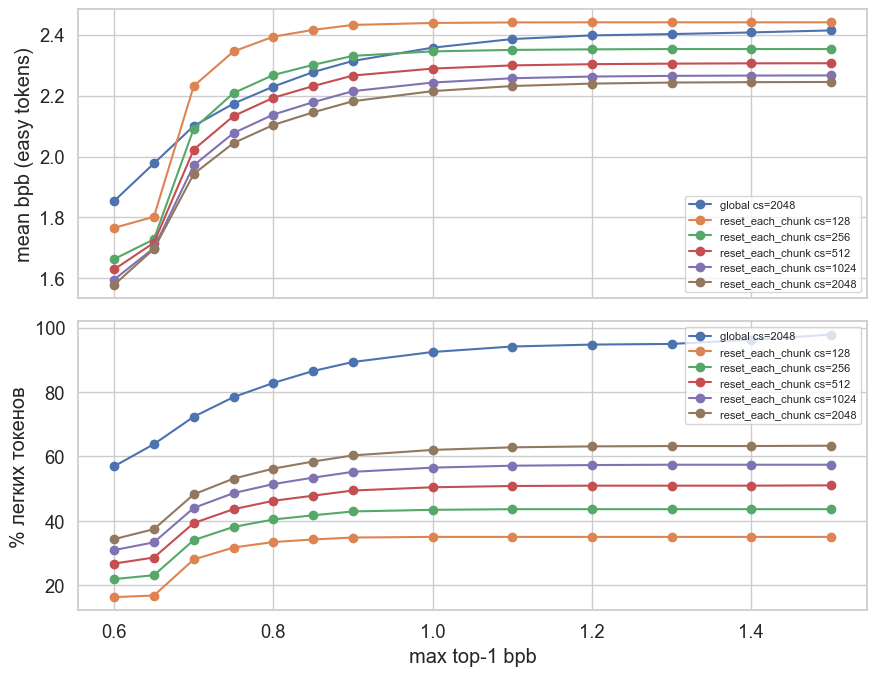

In [8]:
# easy-токены: средний bpb по истинному CE там, где (−log2 p_top1)*BPT_TO_BPB <= порога\n
easy_sub = df_easy.sort_values(
    ["mode", "chunk_size", "max_top1_surprise_bpb"]
)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for (m, cs), grp in easy_sub.groupby(["mode", "chunk_size"], sort=False):
    thr = grp["max_top1_surprise_bpb"]
    ax0.plot(thr, grp["easy_bpb"], marker="o", label=f"{m} cs={cs}")
    ax1.plot(thr, grp["pct_easy"], marker="o", label=f"{m} cs={cs}")
ax0.set_ylabel("mean bpb (easy tokens)")
ax0.legend(fontsize=8)
ax0.grid(True)
ax1.set_xlabel("max top-1 bpb")
ax1.set_ylabel("% легких токенов")
ax1.legend(fontsize=8)
ax1.grid(True)
plt.tight_layout()
plt.show()

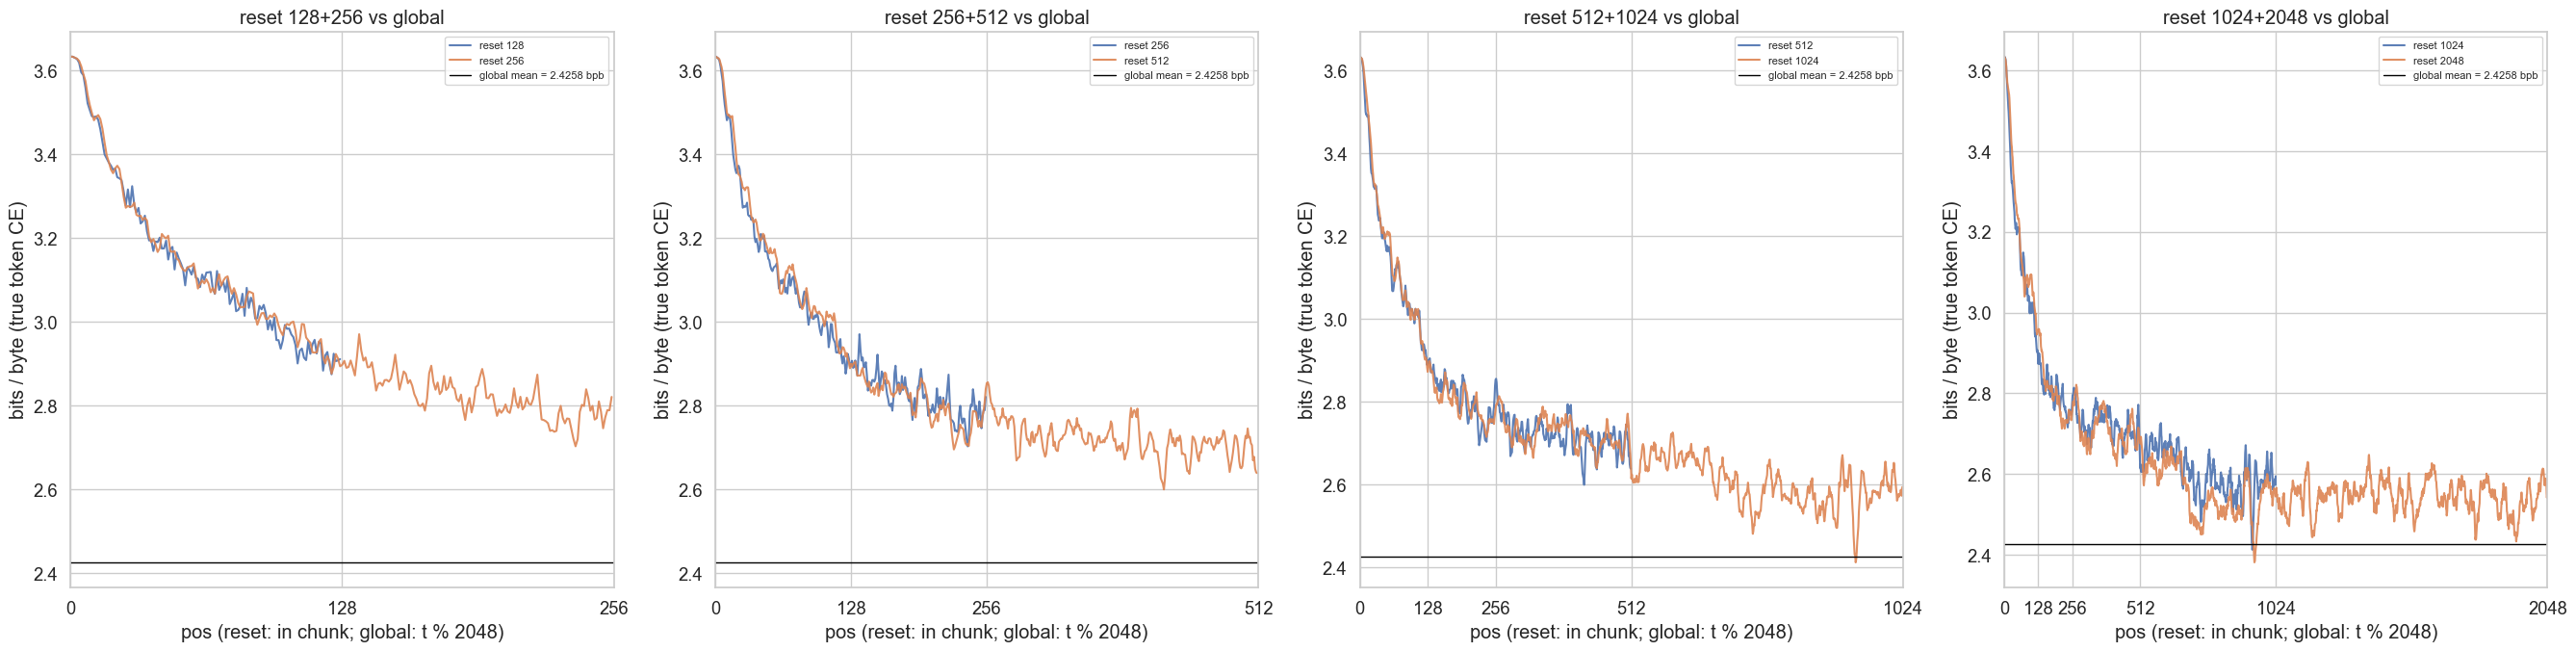

In [9]:
subset = df_position
global_df = subset[subset["mode"] == "global"].sort_values("pos_in_chunk")

fig, axes = plt.subplots(1, 4, figsize=(27, 7), sharey=False)
for ax, (a, b) in zip(axes, PANEL_PAIRS):
    xmax = max(a, b)
    for cs in (a, b):
        d = subset[
            (subset["mode"] == "reset_each_chunk") & (subset["chunk_size"] == cs)
        ].sort_values("pos_in_chunk")
        d = d[d["pos_in_chunk"] <= xmax]
        window = max(1, cs // 100)
        y = d["avg_bpb"].rolling(window, min_periods=1).mean()
        ax.plot(d["pos_in_chunk"], y, ls="-", alpha=0.9, label=f"reset {cs}")
    #gd = global_df[global_df["pos_in_chunk"] <= xmax]
    ax.axhline(g_bpb, color="black", lw=1.0, ls="-", label=f"global mean = {g_bpb:.4f} bpb")
    # ax.plot(gd["pos_in_chunk"], gd["avg_bpb"], color="black", lw=1.2, label="global")
    ax.set_xlim(0, xmax)
    ax.set_xticks([x for x in XTICKS if x <= xmax])
    ax.set_xlabel("pos (reset: in chunk; global: t % 2048)")
    ax.set_ylabel("bits / byte (true token CE)")
    ax.set_title(f"reset {a}+{b} vs global")
    ax.legend(fontsize=8)

#fig.suptitle(f"Cross-entropy (true token) — {TOK_NAME}", y=1.02)
plt.tight_layout()
plt.savefig("warmup_bpb_panels.png", dpi=150, bbox_inches="tight")
plt.show()

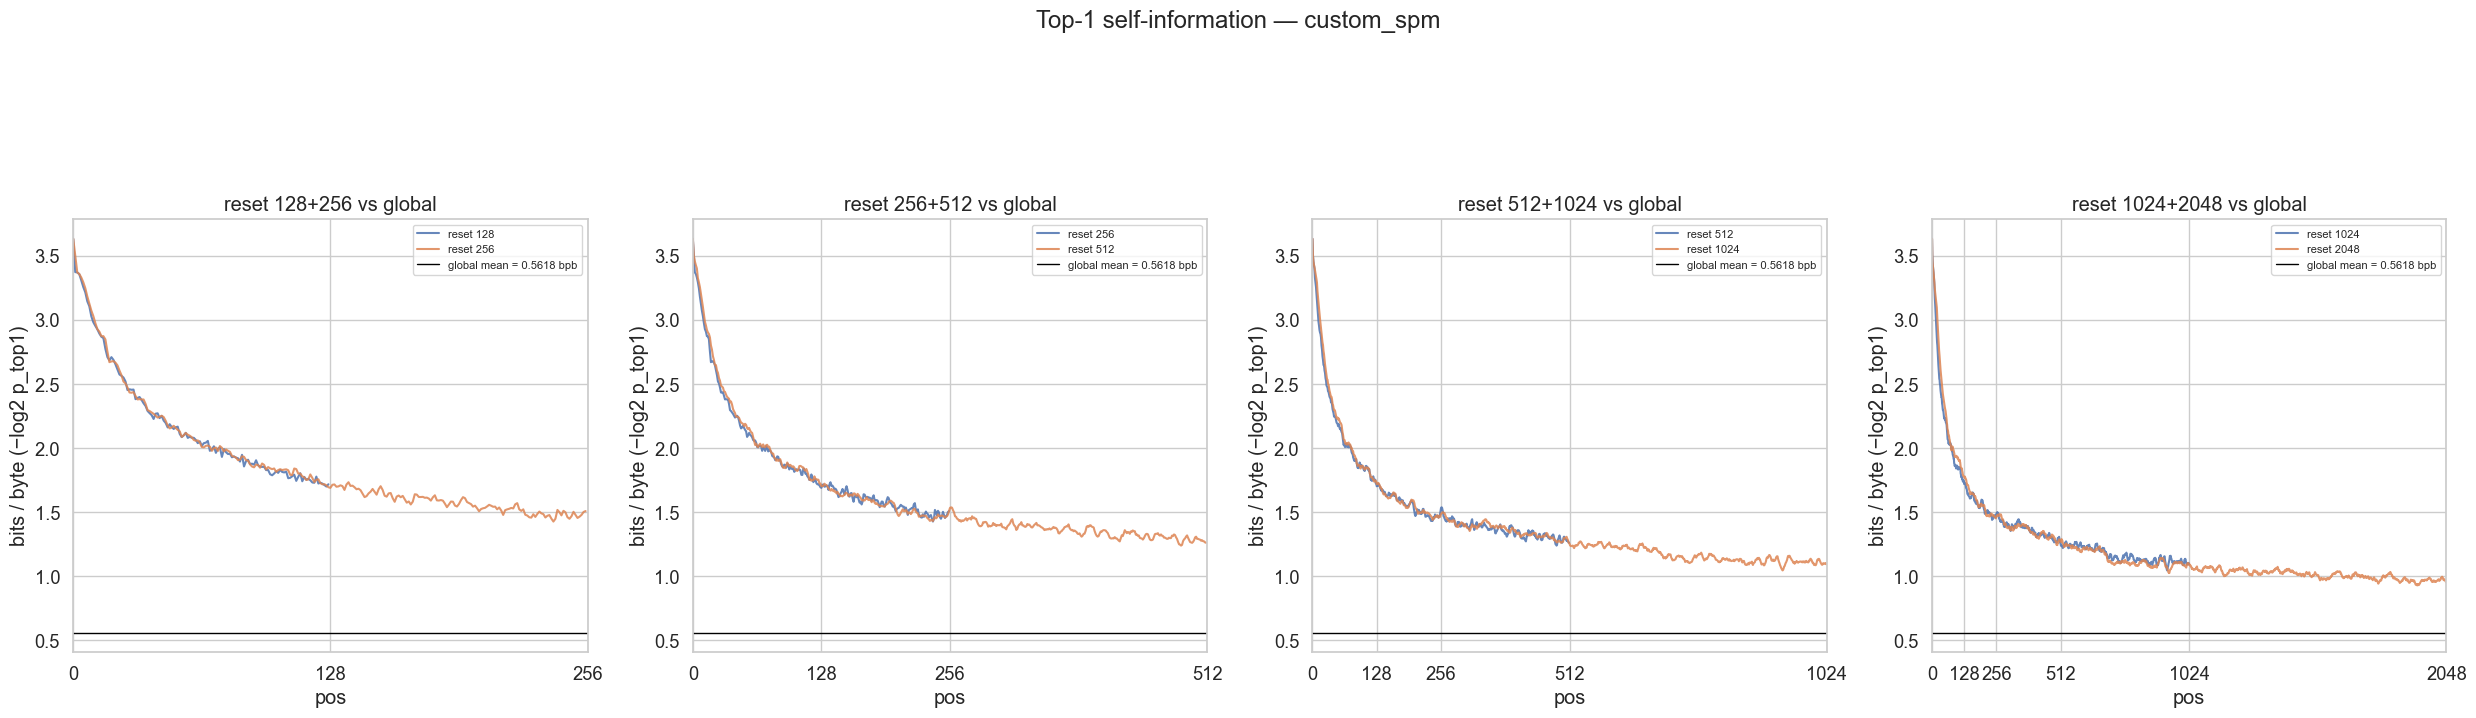

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(25, 6), sharey=False)
for ax, (a, b) in zip(axes, PANEL_PAIRS):
    xmax = max(a, b)
    for cs in (a, b):
        d = subset[
            (subset["mode"] == "reset_each_chunk") & (subset["chunk_size"] == cs)
        ].sort_values("pos_in_chunk")
        d = d[d["pos_in_chunk"] <= xmax]
        window = max(1, cs // 100)
        y = d["avg_top1_bpb"].rolling(window, min_periods=1).mean()
        ax.plot(d["pos_in_chunk"], y, ls="-", alpha=0.85, label=f"reset {cs}")
    gd = global_df[global_df["pos_in_chunk"] <= xmax]
    # ax.plot(gd["pos_in_chunk"], gd["avg_top1_bpb"], color="black", lw=1, label="global")
    ax.axhline(g_top1_bpb, color="black", lw=1.0, ls="-", label=f"global mean = {g_top1_bpb:.4f} bpb")
    ax.set_xlim(0, xmax)
    ax.set_xticks([x for x in XTICKS if x <= xmax])
    ax.set_xlabel("pos")
    ax.set_ylabel("bits / byte (−log2 p_top1)")
    ax.set_title(f"reset {a}+{b} vs global")
    ax.legend(fontsize=8)

fig.suptitle(f"Top-1 self-information — {TOK_NAME}", y=1.2)
plt.tight_layout()
plt.savefig("top1_bpb_panels.png", dpi=200, bbox_inches="tight")
plt.show()

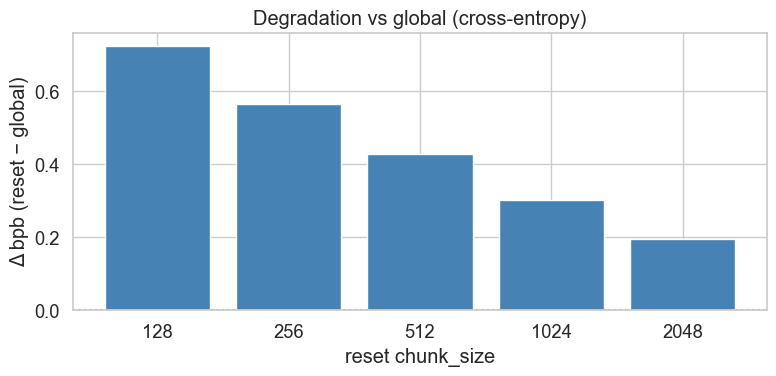

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
x = deltas.index.astype(int)
ax.bar(x.astype(str), deltas["Δ_bpb"], color="steelblue")
ax.axhline(0, color="gray", ls=":")
ax.set_xlabel("reset chunk_size")
ax.set_ylabel("Δ bpb (reset − global)")
ax.set_title("Degradation vs global (cross-entropy)")
plt.tight_layout()
plt.savefig("delta_bpb_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
df_summary

,mode,chunk_size,avg_entropy,avg_bpb,std_entropy,avg_top1_entropy,avg_top1_bpb,total_tokens,time_sec
0,global,2048,9.346329,2.425802,8.015554,2.164535,0.561796,259546,43.1
1,reset_each_chunk,128,12.132572,3.148961,4.244587,8.447372,2.192482,259546,24.5
2,reset_each_chunk,256,11.515137,2.988708,4.791560,7.260186,1.884352,259546,26.4
3,reset_each_chunk,512,10.987399,2.851735,5.179635,6.235942,1.618514,259546,27.7
4,reset_each_chunk,1024,10.505879,2.726759,5.486815,5.361832,1.391642,259546,30.0
5,reset_each_chunk,2048,10.096628,2.620539,5.738027,4.609501,1.196378,259546,36.9
